<center>
    <h1 style = "color:blue"> Lab 2 - Data Modeling and Fitting</h1>
</center>

<img src="Images/machine_learning.jpg" width=200; height=200>

<center>
<h2>Multiple Variable Linear Regression
    
<img src="Images/std_dev.png" width=200; height=200>


    By Joshua Brewington

Objectives
- Create a professional looking Jupyter Notebook
- Create and use Machine Learning Models with SciKit Learn
- Learn how generate data using SciKit Learn
- Use Python inline Lamda to create a function to model the data 
- Learn more advanced NumPy (Numerical Python) array features 
- Perform Multiple Regression Analysis with SciKit Learn
     - Train-Test Split of data with SciKit Learn
- Create and Test Predictive Models
- Perform Model Evaluation
     - Model Score and Accuracy
- Perform 3D Plotting with MatPlotLib

<u><h2>Introduction

In lab 1, we fitted a trend line to a dataset through linear regression. Lab 1 used univariate (single variable) to predict the dependent variable. If there are datasets that deal with multiple dimensions (multiple independent variables), Scikit-learn will be implemented. Scikit-learn has tools such as Lasso and ridge regression which allows us to deal with multivariable. For now, we will use ordinary least squares reggression function, which solves mathematical problems of the form

<h2 style="text-align:center; color:indigo;">
           $\frac{\min}{w}\;\left\| {y - Xw} \right\|$
</h2>

where w is the set of coefficients. The number of coefficients depends on the number of dimensions in the data, N(coeff) =MD − 1, where M >1 and is an integer.


<u><h2>Creating a Predictive Model

In [1]:
%matplotlib inline
import numpy as np
from sklearn import linear_model
#from skylearn.datasets.samples_generator import make_regression
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#Generating synthetic data for training and testing. 100 samples with two input features
X,y = make_regression(n_samples=100, n_features=2, n_informative=1, random_state=0, noise=50)
X_train, X_test = X[:80], X[-20:]
y_train, y_test = y[:80], y[-20:]

#print(X_train[:,0])

# creating instance of model
regr = linear_model.LinearRegression()

#training the model
regr.fit(X_train, y_train)

#printing the coefficients
print(regr.coef_)

[-10.25691752  90.5463984 ]


<u><h2> Model Evaluation

<h3 style="color:green"> Predicting y-value based on the training

In [2]:
#Predicting y-value based on the training
X1=np.array([1,-1])
#reshape the array so numpy can use it
X1=np.reshape(X1, (1,-1))
#X1=np.array([1.2,4])
print(regr.predict(X1))

print(regr.score(X_test, y_test))

[-99.82024461]
0.9498274922607957


<u><h2> Creating 3D Plots with MatPlotLib

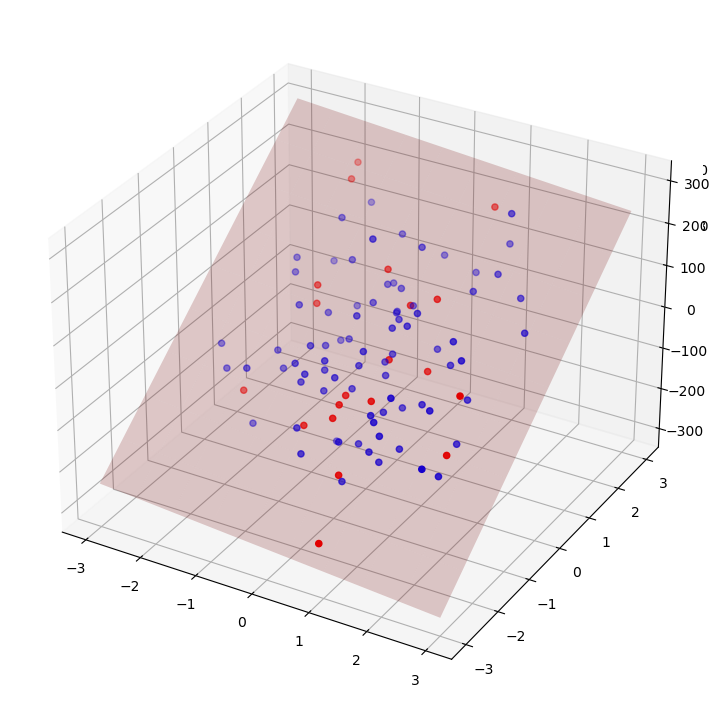

In [3]:
#Data
#define an inline functioon (using Lambda) with coefficient variables
#returned from the regression analysis
coef=regr.coef_
line=lambda x1, x2: coef[0]*x1 + coef[1]*x2
#plotting
fig = plt.figure(figsize=(9,9))
grid_x1, grid_x2 = np.mgrid[-3:3:10j, -3:3:10j]
ax = fig.add_subplot(111, projection='3d', auto_add_to_figure=False)
fig.add_axes(ax)
ax = plt.axes(projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], y_train, facecolor='blue')
ax.scatter(X_test[:,0], X_test[:,1], y_test, facecolor='red')
ax.plot_surface(grid_x1, grid_x2, line(grid_x1, grid_x2), alpha=0.2, color='red')
# show the plot
#ax.view_init(50,0)
plt.show()

## Save the plot as a pdf file:

In [4]:
#fig.savefig('MLR_Lab_2_50,0.pdf', bbox_inches='tight')